Fourier Series

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
from scipy.signal import argrelextrema

In [36]:
def csv_reader(file_name):
    """
    Reads CSV, handles formatting, removes bad data, and returns aligned arrays.
    """
    df = pd.read_csv(file_name)
    
    # convert to date time objects
    if pd.api.types.is_numeric_dtype(df['Date']):
        df['Date'] = pd.to_datetime(df['Date'], unit='D')
    else:
        df['Date'] = pd.to_datetime(df['Date'])

    # sorting by date
    df = df.sort_values('Date')

    df = df.dropna(subset=['Date', 'Adj Close'])

    # dates to int
    start_date = df['Date'].min()
    df['Days'] = (df['Date'] - start_date).dt.days

    x_data = df['Days'].values
    y_data = df['Adj Close'].values
    
    # return dates for plotting
    original_dates = df['Date'].values
    
    return x_data, y_data, original_dates

In [37]:
def fit_fourier_series(x_data, y_data, num_harmonics, period=None):

    # numpy arrays
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    # period
    if period is None:
        period = np.max(x_data) - np.min(x_data)
        
    omega = 2 * np.pi / period
    
    # Start with a column of 1s for the intercept (a0 / DC offset)
    A = [np.ones_like(x_data)]
    
    # Append cos and sin terms for each harmonic
    for n in range(1, num_harmonics + 1):
        A.append(np.cos(n * omega * x_data))
        A.append(np.sin(n * omega * x_data))
        
    # Transpose to get correct shape 
    A = np.vstack(A).T
    
    # Solve the Least Squares problem: A * coeffs = y_data
    coeffs, residuals, rank, s = np.linalg.lstsq(A, y_data, rcond=None)
    
    # Reconstruct the fitted curve
    y_fit = A @ coeffs

    return y_fit, coeffs

In [38]:
def fit_fourier_with_trend(x_data, y_data, num_harmonics, period=None):
    # Fit a linear trend line (y = mx + c)
    m, c = np.polyfit(x_data, y_data, 1)
    linear_trend = m * x_data + c
    
    # 2. Subtract the trend (detrending)
    y_detrended = y_data - linear_trend
    
    # 3. Fit Fourier series
    if period==None:
        period = np.max(x_data) - np.min(x_data)
    
    
    # period = 365    ##hardset for 1-year cycles if needed
    
    
    omega = 2 * np.pi / period
    
    A = [np.ones_like(x_data)]
    for n in range(1, num_harmonics + 1):
        A.append(np.cos(n * omega * x_data))
        A.append(np.sin(n * omega * x_data))
    A = np.vstack(A).T
    
    coeffs, _, _, _ = np.linalg.lstsq(A, y_detrended, rcond=None)
    y_wiggles = A @ coeffs
    
    #Add the trend
    y_final = linear_trend + y_wiggles
    
    return y_final, coeffs

Stock Testing (APPL)

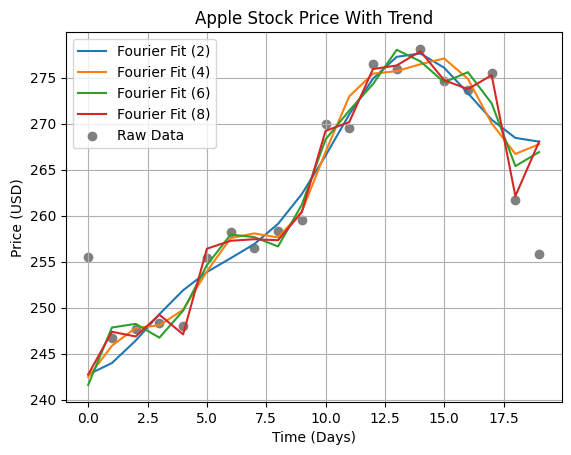

In [39]:
# x = Days (0 to 19)
x_data = np.arange(20)

# y = AAPL Closing Prices (Jan 16 - Feb 13, 2026)
y_data = np.array([
    255.53, 246.70, 247.65, 248.35, 248.04, 
    255.41, 258.27, 256.44, 258.28, 259.48, 
    270.01, 269.48, 276.49, 275.91, 278.12, 
    274.62, 273.68, 275.50, 261.73, 255.78
])


for i in range(2, 10, 2):
    
    y_fit, coeffs=fit_fourier_with_trend(x_data, y_data, i)
    
    plt.plot(x_data, y_fit, label=(f"Fourier Fit ({i})")) 
    


### Constant ###
plt.scatter(x_data, y_data, label='Raw Data', color="gray")
plt.title("Apple Stock Price With Trend")
plt.xlabel("Time (Days)")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


Corn Future Modeling

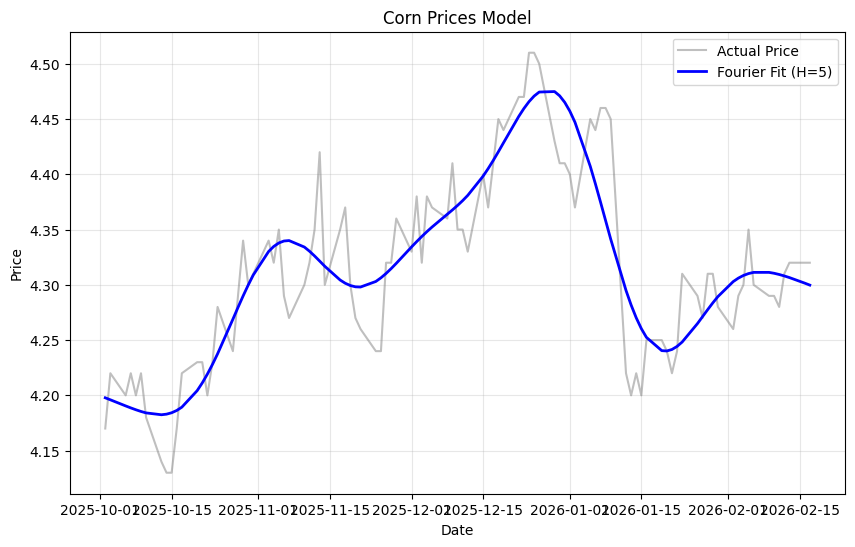

In [40]:
# 1. READ ALL 3 VALUES (The Fix)
# We get 'days' for the math, and 'dates' for the plot
corn_days, corn_price, corn_dates = csv_reader('data/corn_price.csv') 

# 2. FIT THE MODEL
# Crucial: Pass 'corn_days' (integers) to the math function, NOT dates
harmonics = 5
y_fit, coeffs = fit_fourier_with_trend(corn_days, corn_price, harmonics)

# 3. PLOT
plt.figure(figsize=(10, 6))

plt.plot(corn_dates, corn_price, label='Actual Price', color='gray', alpha=0.5)
plt.plot(corn_dates, y_fit, label=f'Fourier Fit (H={harmonics})', color='blue', linewidth=2)

plt.title("Corn Prices Model")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Prediction Testing Corn

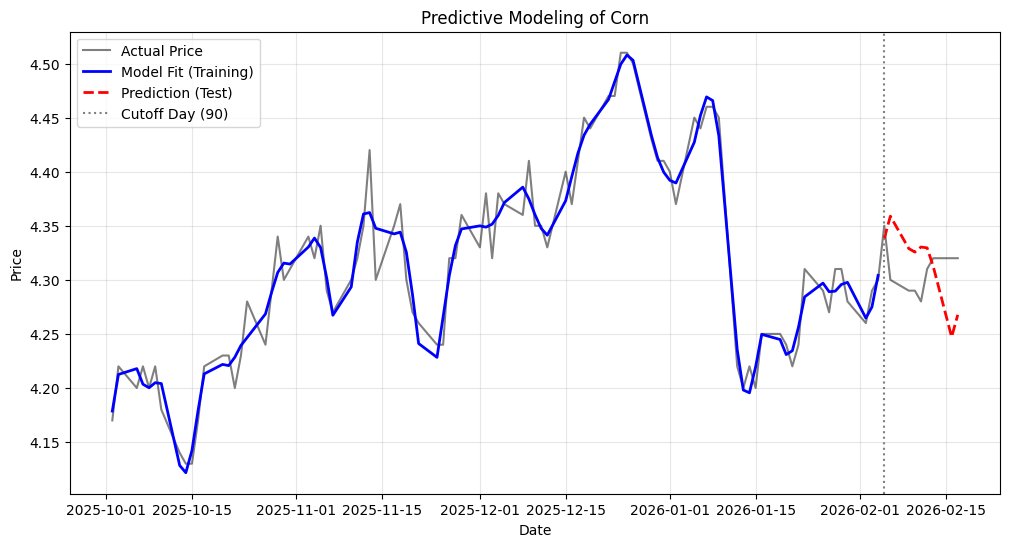

Mean Absolute Error on Prediction: $0.0387


In [41]:
# --- BACKTESTING SCRIPT (Train on 90, Predict 10) ---

# 1. Load Data
# (Ensuring we have the clean integers for math and dates for plotting)
corn_days, corn_price, corn_dates = csv_reader('data/corn_price.csv')

# 2. Define Split
cutoff = 90  # Train on first 90 days
x_train = corn_days[:cutoff]
y_train = corn_price[:cutoff]

x_test = corn_days[cutoff:]
y_test = corn_price[cutoff:]

# 3. Fit Linear Trend (On Training Data Only)
m, c = np.polyfit(x_train, y_train, 1)
trend_train = m * x_train + c

# Project Trend to the FULL range (0 to 100)
trend_full = m * corn_days + c 

# 4. Fit Fourier Series (On Detrended Training Data)
y_detrended = y_train - trend_train

# Calculate period/omega from Training Data
period = np.max(x_train) - np.min(x_train)
omega = 2 * np.pi / period
harmonics = 20

# Build Matrix A for Training
A_train = [np.ones_like(x_train)]
for n in range(1, harmonics + 1):
    A_train.append(np.cos(n * omega * x_train))
    A_train.append(np.sin(n * omega * x_train))
A_train = np.vstack(A_train).T

# Solve for Coefficients
coeffs, _, _, _ = np.linalg.lstsq(A_train, y_detrended, rcond=None)

# 5. Predict the Future (Project Fourier to Full Range)
# We build a new Matrix A for ALL days using the SAME omega
A_full = [np.ones_like(corn_days)]
for n in range(1, harmonics + 1):
    A_full.append(np.cos(n * omega * corn_days))
    A_full.append(np.sin(n * omega * corn_days))
A_full = np.vstack(A_full).T

# Calculate the wave for the full range
wave_full = A_full @ coeffs

# Combine Trend + Wave
y_prediction = trend_full + wave_full

# 6. Plotting
plt.figure(figsize=(12, 6))

# Plot Actual Data
plt.plot(corn_dates, corn_price, color='black', alpha=0.5, label='Actual Price')

# Plot Prediction (Blue for Training, Red Dashed for Test)
plt.plot(corn_dates[:cutoff], y_prediction[:cutoff], color='blue', linewidth=2, label='Model Fit (Training)')
plt.plot(corn_dates[cutoff:], y_prediction[cutoff:], color='red', linestyle='--', linewidth=2, label='Prediction (Test)')

# Visual Separator
plt.axvline(x=corn_dates[cutoff], color='gray', linestyle=':', label='Cutoff Day (90)')

plt.title(f"Predictive Modeling of Corn")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 7. Accuracy Metrics
mae  = np.mean(np.abs(y_prediction[cutoff:] - y_test))
rmse = np.sqrt(np.mean((y_prediction[cutoff:] - y_test)**2))
mape = np.mean(np.abs((y_prediction[cutoff:] - y_test) / y_test)) * 100
ss_res = np.sum((y_test - y_prediction[cutoff:])**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - ss_res / ss_tot
print(f"Corn Backtest | MAE: ${mae:.4f}  RMSE: ${rmse:.4f}  MAPE: {mape:.2f}%  R\u00b2: {r2:.4f}")


Soy Modeling

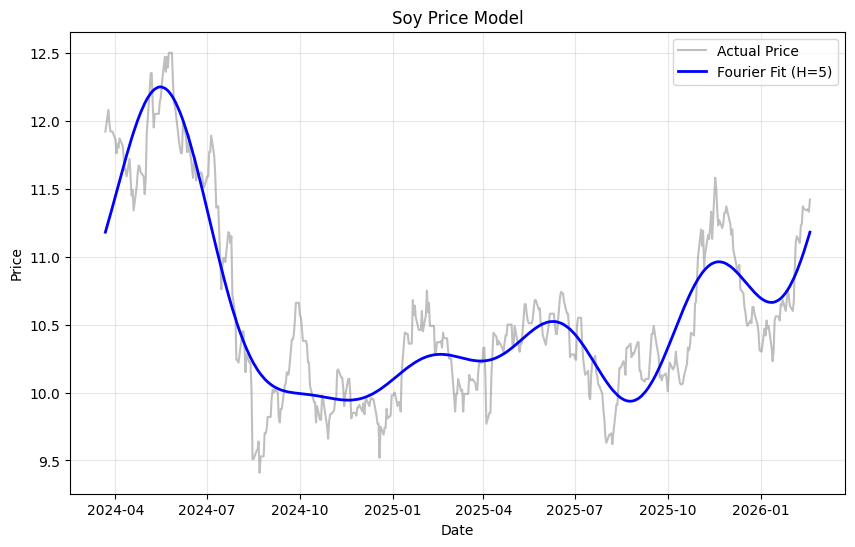

In [42]:
# 1. READ ALL 3 VALUES (The Fix)
# We get 'days' for the math, and 'dates' for the plot
soy_days, soy_price, soy_dates = csv_reader('data/soy_price.csv') 

# 2. FIT THE MODEL
# Crucial: Pass 'corn_days' (integers) to the math function, NOT dates
harmonics = 5
y_fit, coeffs = fit_fourier_series(soy_days, soy_price, harmonics)

# 3. PLOT
plt.figure(figsize=(10, 6))

# Plot using 'corn_dates' so the X-axis shows real calendar days
plt.plot(soy_dates, soy_price, label='Actual Price', color='gray', alpha=0.5)
plt.plot(soy_dates, y_fit, label=f'Fourier Fit (H={harmonics})', color='blue', linewidth=2)

plt.title("Soy Price Model")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Soy Predictive Modeling

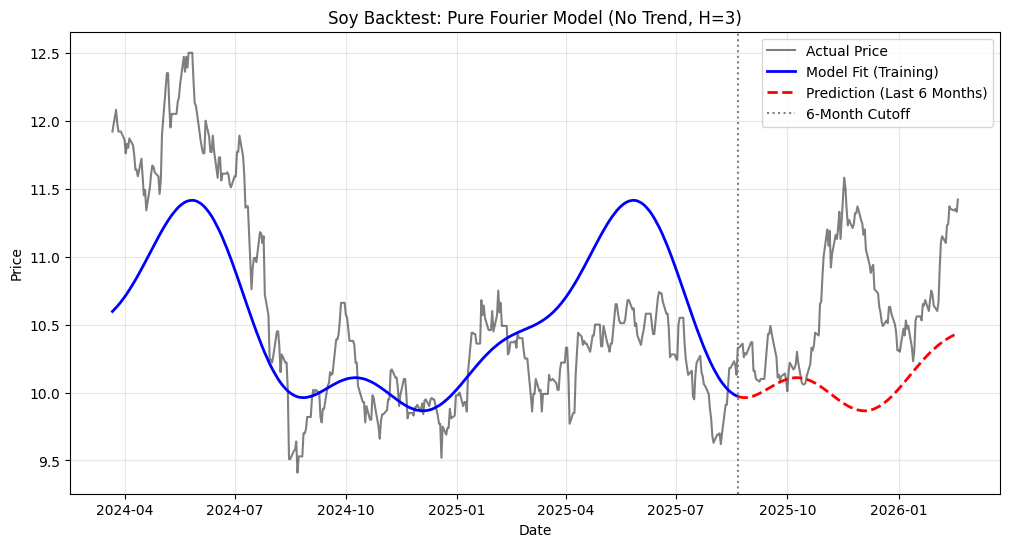

Mean Absolute Error on 6-Month Prediction: $0.5783


In [43]:
# 1. Load Data
soy_days, soy_price, soy_dates = csv_reader('data/soy_price.csv') 

# 2. Define Split (Leave the last 6 months for prediction)
cutoff_date = soy_dates[-1] - np.timedelta64(182, 'D')
cutoff = np.searchsorted(soy_dates, cutoff_date)

x_train = soy_days[:cutoff]
y_train = soy_price[:cutoff]

x_test = soy_days[cutoff:]
y_test = soy_price[cutoff:]

# --- TREND CODE COMPLETELY REMOVED ---

# 3. Fit Pure Fourier Series (Directly on Training Data)
period = 365
omega = 2 * np.pi / period
harmonics = 3

# Build Matrix A for Training
A_train = [np.ones_like(x_train)]
for n in range(1, harmonics + 1):
    A_train.append(np.cos(n * omega * x_train))
    A_train.append(np.sin(n * omega * x_train))
A_train = np.vstack(A_train).T

# Solve for Coefficients (Using y_train directly, not detrended!)
coeffs, _, _, _ = np.linalg.lstsq(A_train, y_train, rcond=None)

# 4. Predict the Future (Project pure Fourier to Full Range)
A_full = [np.ones_like(soy_days)]
for n in range(1, harmonics + 1):
    A_full.append(np.cos(n * omega * soy_days))
    A_full.append(np.sin(n * omega * soy_days))
A_full = np.vstack(A_full).T

# The wave IS the prediction now
y_prediction = A_full @ coeffs

# 5. Plotting
plt.figure(figsize=(12, 6))

# Plot Actual Data
plt.plot(soy_dates, soy_price, color='black', alpha=0.5, label='Actual Price')

# Plot Prediction (Blue for Training, Red Dashed for Test)
plt.plot(soy_dates[:cutoff], y_prediction[:cutoff], color='blue', linewidth=2, label='Model Fit (Training)')
plt.plot(soy_dates[cutoff:], y_prediction[cutoff:], color='red', linestyle='--', linewidth=2, label='Prediction (Last 6 Months)')

# Visual Separator
plt.axvline(x=soy_dates[cutoff], color='gray', linestyle=':', label='6-Month Cutoff')

plt.title(f"Soy Backtest: Pure Fourier Model (No Trend, H={harmonics})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 7. Accuracy Metrics
mae  = np.mean(np.abs(y_prediction[cutoff:] - y_test))
rmse = np.sqrt(np.mean((y_prediction[cutoff:] - y_test)**2))
mape = np.mean(np.abs((y_prediction[cutoff:] - y_test) / y_test)) * 100
ss_res = np.sum((y_test - y_prediction[cutoff:])**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - ss_res / ss_tot
print(f"Soy 6-Month Backtest | MAE: ${mae:.4f}  RMSE: ${rmse:.4f}  MAPE: {mape:.2f}%  R\u00b2: {r2:.4f}")


Future Soy Prediction

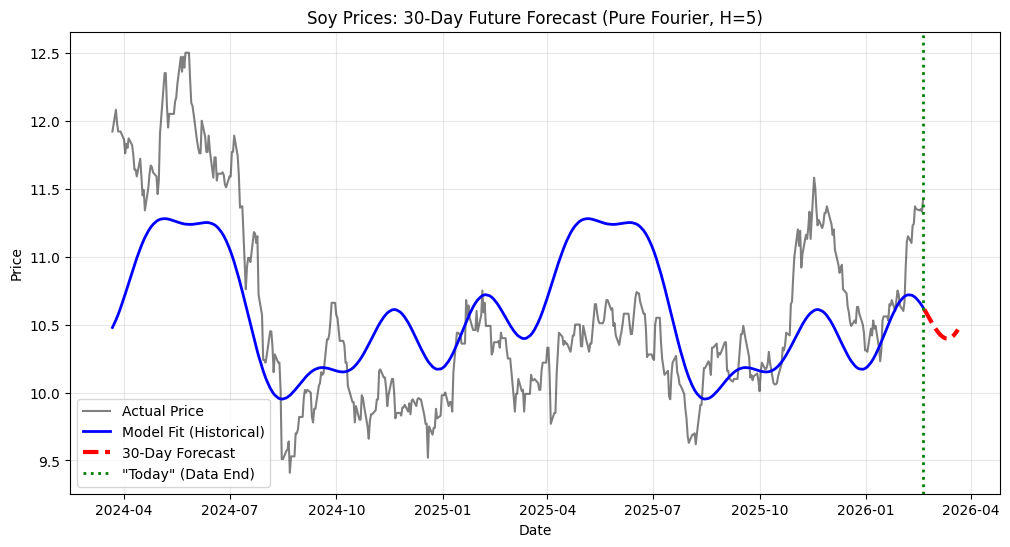

Last Known Price (2026-02-19): $11.42
Predicted Price in 30 Days (2026-03-21): $10.46


In [44]:
# 1. Load ALL Data (No Train/Test Split)
soy_days, soy_price, soy_dates = csv_reader('data/soy_price.csv') 

# 2. Setup Math for Pure Fourier
period = 365
omega = 2 * np.pi / period
harmonics = 5

# 3. Train on 100% of the historical data
A_train = [np.ones_like(soy_days)]
for n in range(1, harmonics + 1):
    A_train.append(np.cos(n * omega * soy_days))
    A_train.append(np.sin(n * omega * soy_days))
A_train = np.vstack(A_train).T

# Solve for Coefficients using ALL data
coeffs, _, _, _ = np.linalg.lstsq(A_train, soy_price, rcond=None)

# 4. Create the "Future" Timeline (Next 30 Days)
future_days_count = 30
last_day = soy_days[-1]
last_date = soy_dates[-1]

# Generate the new numeric days (e.g., if last day was 699, this makes 700 to 729)
future_days = np.arange(last_day + 1, last_day + 1 + future_days_count)

# Generate the actual calendar dates for the X-axis
future_dates = np.array([last_date + np.timedelta64(i, 'D') for i in range(1, future_days_count + 1)])

# Combine historical + future into one continuous timeline
all_days = np.concatenate([soy_days, future_days])
all_dates = np.concatenate([soy_dates, future_dates])

# 5. Predict the Entire Timeline (Past + Future)
A_all = [np.ones_like(all_days)]
for n in range(1, harmonics + 1):
    A_all.append(np.cos(n * omega * all_days))
    A_all.append(np.sin(n * omega * all_days))
A_all = np.vstack(A_all).T

# The full wave
y_all_predictions = A_all @ coeffs

# Separate the predictions into "Historical Fit" and "Future Forecast"
historical_fit = y_all_predictions[:len(soy_days)]
future_forecast = y_all_predictions[len(soy_days):]

# 6. Plotting
plt.figure(figsize=(12, 6))

# Plot Actual Historical Data
plt.plot(soy_dates, soy_price, color='black', alpha=0.5, label='Actual Price')

# Plot Historical Fit (Blue)
plt.plot(soy_dates, historical_fit, color='blue', linewidth=2, label='Model Fit (Historical)')

# Plot Future Forecast (Red, Thick, Dashed)
plt.plot(future_dates, future_forecast, color='red', linestyle='--', linewidth=3, label='30-Day Forecast')

# Visual Separator for "Today"
plt.axvline(x=last_date, color='green', linestyle=':', linewidth=2, label='"Today" (Data End)')

plt.title(f"Soy Prices: 30-Day Future Forecast (Pure Fourier, H={harmonics})")
plt.xlabel("Date")
plt.ylabel("Price")

# Legend and Grid
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Print the final price prediction for Day 30
print(f"Last Known Price ({np.datetime_as_string(last_date, unit='D')}): ${soy_price[-1]:.2f}")
print(f"Predicted Price in 30 Days ({np.datetime_as_string(future_dates[-1], unit='D')}): ${future_forecast[-1]:.2f}")

Oil Price Modeling

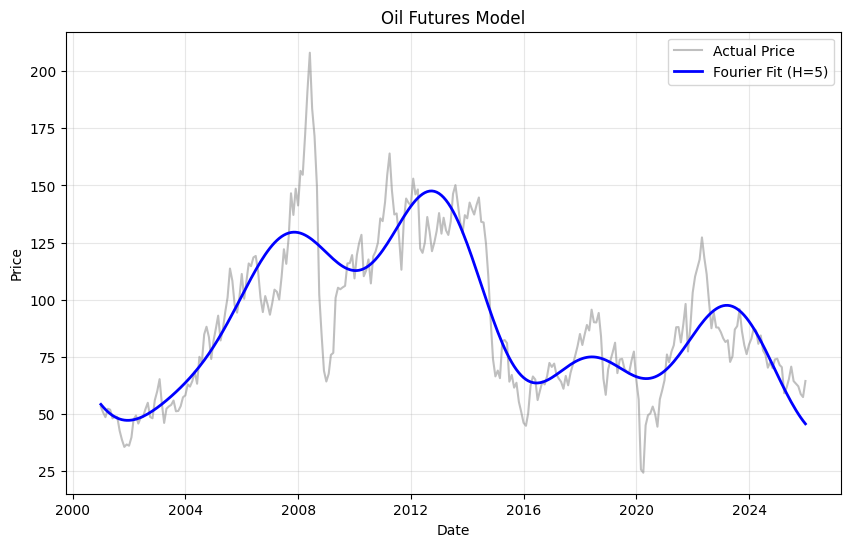

In [45]:
# 1. READ ALL 3 VALUES (The Fix)
# We get 'days' for the math, and 'dates' for the plot
oil_days, oil_price, oil_dates = csv_reader('data/oil_price.csv') 

# 2. FIT THE MODEL
harmonics = 5
y_fit, coeffs = fit_fourier_with_trend(oil_days, oil_price, harmonics)

# 3. PLOT
plt.figure(figsize=(10, 6))


plt.plot(oil_dates, oil_price, label='Actual Price', color='gray', alpha=0.5)
plt.plot(oil_dates, y_fit, label=f'Fourier Fit (H={harmonics})', color='blue', linewidth=2)

plt.title("Oil Futures Model")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

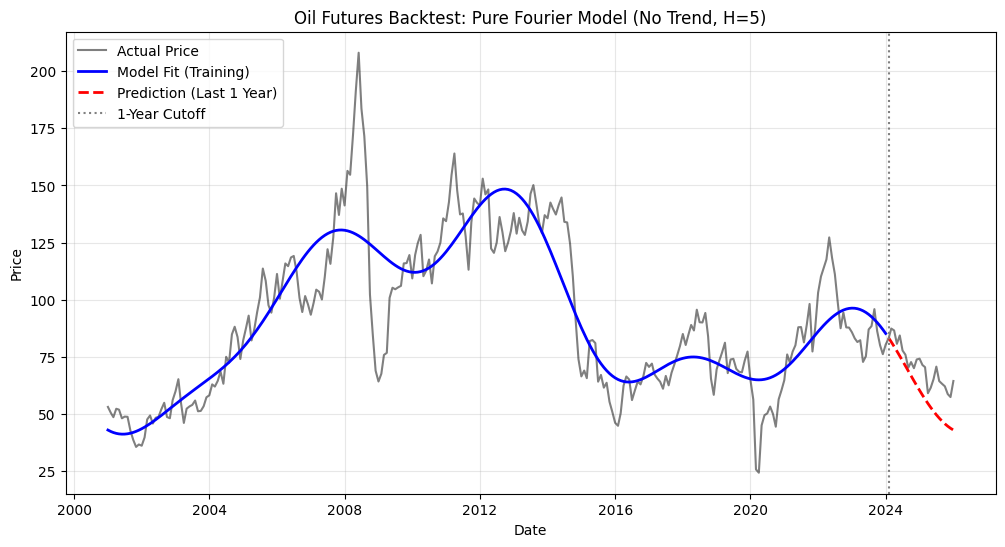

Mean Absolute Error on 1-Year Prediction: $10.2681


In [46]:
# 1. Load Data
oil_days, oil_price, oil_dates = csv_reader('data/oil_price.csv') 

# 2. Define Split (Leave the last 1 Year / 365 days for prediction)
cutoff_date = oil_dates[-1] - np.timedelta64(2*365, 'D')
cutoff = np.searchsorted(oil_dates, cutoff_date)

x_train = oil_days[:cutoff]
y_train = oil_price[:cutoff]

x_test = oil_days[cutoff:]
y_test = oil_price[cutoff:]

# 3. Fit Pure Fourier Series (Directly on Training Data, No Trend)
period = 365
period = np.max(oil_days) - np.min(oil_days)
omega = 2 * np.pi / period

# 3 harmonics captures the primary yearly cycle + half-year + quarterly shifts
harmonics = 5

# Build Matrix A for Training
A_train = [np.ones_like(x_train)]
for n in range(1, harmonics + 1):
    A_train.append(np.cos(n * omega * x_train))
    A_train.append(np.sin(n * omega * x_train))
A_train = np.vstack(A_train).T

# Solve for Coefficients (Using y_train directly)
coeffs, _, _, _ = np.linalg.lstsq(A_train, y_train, rcond=None)

# 4. Predict the Future (Project pure Fourier to Full Range)
A_full = [np.ones_like(oil_days)]
for n in range(1, harmonics + 1):
    A_full.append(np.cos(n * omega * oil_days))
    A_full.append(np.sin(n * omega * oil_days))
A_full = np.vstack(A_full).T

# The wave IS the prediction now
y_prediction = A_full @ coeffs

# 5. Plotting
plt.figure(figsize=(12, 6))

# Plot Actual Data
plt.plot(oil_dates, oil_price, color='black', alpha=0.5, label='Actual Price')

# Plot Prediction (Blue for Training, Red Dashed for Test)
plt.plot(oil_dates[:cutoff], y_prediction[:cutoff], color='blue', linewidth=2, label='Model Fit (Training)')
plt.plot(oil_dates[cutoff:], y_prediction[cutoff:], color='red', linestyle='--', linewidth=2, label='Prediction (Last 1 Year)')

# Visual Separator
plt.axvline(x=oil_dates[cutoff], color='gray', linestyle=':', label='1-Year Cutoff')

plt.title(f"Oil Futures Backtest: Pure Fourier Model (No Trend, H={harmonics})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 7. Accuracy Metrics
mae  = np.mean(np.abs(y_prediction[cutoff:] - y_test))
rmse = np.sqrt(np.mean((y_prediction[cutoff:] - y_test)**2))
mape = np.mean(np.abs((y_prediction[cutoff:] - y_test) / y_test)) * 100
ss_res = np.sum((y_test - y_prediction[cutoff:])**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - ss_res / ss_tot
print(f"Oil 1-Year Backtest | MAE: ${mae:.4f}  RMSE: ${rmse:.4f}  MAPE: {mape:.2f}%  R\u00b2: {r2:.4f}")


In [47]:
# # 1. Load Data
# oil_days, oil_price, oil_dates = csv_reader('oil_future.csv') 

# # 2. Define Split (Leave the last 2 Years for prediction)
# cutoff_date = oil_dates[-1] - np.timedelta64(2*365, 'D')
# cutoff = np.searchsorted(oil_dates, cutoff_date)

# x_train = oil_days[:cutoff]
# y_train = oil_price[:cutoff]

# x_test = oil_days[cutoff:]
# y_test = oil_price[cutoff:]

# # 3. Setup Math
# # NOTE: Your original code had `period = 365` immediately followed by `period = max - min`.
# # It's highly recommended to strictly use 365 for forecasting commodities.
# period = 365
# omega = 2 * np.pi / period

# # 4. START PLOTTING (Do not call plt.show yet!)
# plt.figure(figsize=(14, 8))

# # Plot Actual Data once (Black)
# plt.plot(oil_dates, oil_price, color='black', alpha=0.7, label='Actual Price', linewidth=2)

# # Visual Separator for the cutoff
# plt.axvline(x=oil_dates[cutoff], color='black', linestyle=':', label='2-Year Prediction Cutoff')

# # Setup a colormap so each harmonic gets a different color
# colors = plt.cm.viridis(np.linspace(0, 1, len(range(1, 31))))

# # 5. RUN THE LOOP
# print("--- Accuracy Results ---")
# for idx, i in enumerate(range(1, 31)):
#     harmonics = i

#     # Build Matrix A for Training
#     A_train = [np.ones_like(x_train)]
#     for n in range(1, harmonics + 1):
#         A_train.append(np.cos(n * omega * x_train))
#         A_train.append(np.sin(n * omega * x_train))
#     A_train = np.vstack(A_train).T

#     # Solve for Coefficients (Using y_train directly)
#     coeffs, _, _, _ = np.linalg.lstsq(A_train, y_train, rcond=None)

#     # Predict the Future
#     A_full = [np.ones_like(oil_days)]
#     for n in range(1, harmonics + 1):
#         A_full.append(np.cos(n * omega * oil_days))
#         A_full.append(np.sin(n * omega * oil_days))
#     A_full = np.vstack(A_full).T

#     # The wave IS the prediction now
#     y_prediction = A_full @ coeffs

#     # Plot Prediction inside the loop using our unique color
#     c = colors[idx]
    
#     # We make the training line a bit transparent (alpha=0.4) so it doesn't get too messy
#     # plt.plot(oil_dates[:cutoff], y_prediction[:cutoff], color=c, alpha=0.4) 
    
#     # # We make the prediction line thick and dashed
#     # plt.plot(oil_dates[cutoff:], y_prediction[cutoff:], color=c, linestyle='--', 
#     #          linewidth=2, label=f'Predict (H={harmonics})')

#     # Accuracy Check
#     if len(y_test) > 0:
#         error = np.mean(np.abs(y_prediction[cutoff:] - y_test))
#         print(f"H={harmonics:<2} | Mean Absolute Error: ${error:.4f}")

# # 6. FINISH AND DISPLAY
# plt.title("Oil Futures Backtest: Comparing Harmonic Counts")
# plt.xlabel("Date")
# plt.ylabel("Price")

# # Move the legend outside the plot so it doesn't cover your lines
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.grid(True, alpha=0.3)
# plt.tight_layout() # Ensures the legend doesn't get cut off the screen
# plt.show() # NOW we show the picture!

Gold Future Modeling

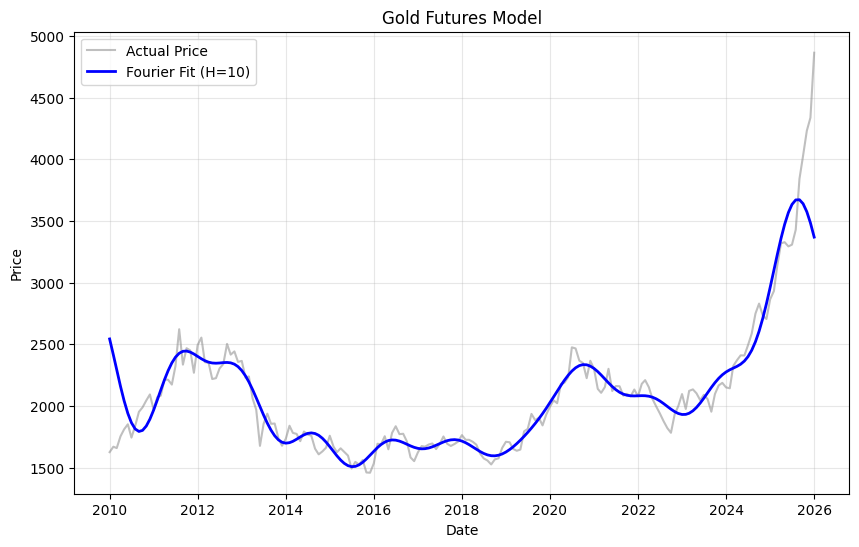

In [48]:
# 1. READ ALL 3 VALUES (The Fix)
# We get 'days' for the math, and 'dates' for the plot
gold_days, gold_price, gold_dates = csv_reader('data/gold_price.csv') 

# 2. FIT THE MODEL
harmonics = 10
y_fit, coeffs = fit_fourier_with_trend(gold_days, gold_price, harmonics)

# 3. PLOT
plt.figure(figsize=(10, 6))


plt.plot(gold_dates, gold_price, label='Actual Price', color='gray', alpha=0.5)
plt.plot(gold_dates, y_fit, label=f'Fourier Fit (H={harmonics})', color='blue', linewidth=2)

plt.title("Gold Futures Model")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Teucrium Soybean Fund (SOYB)

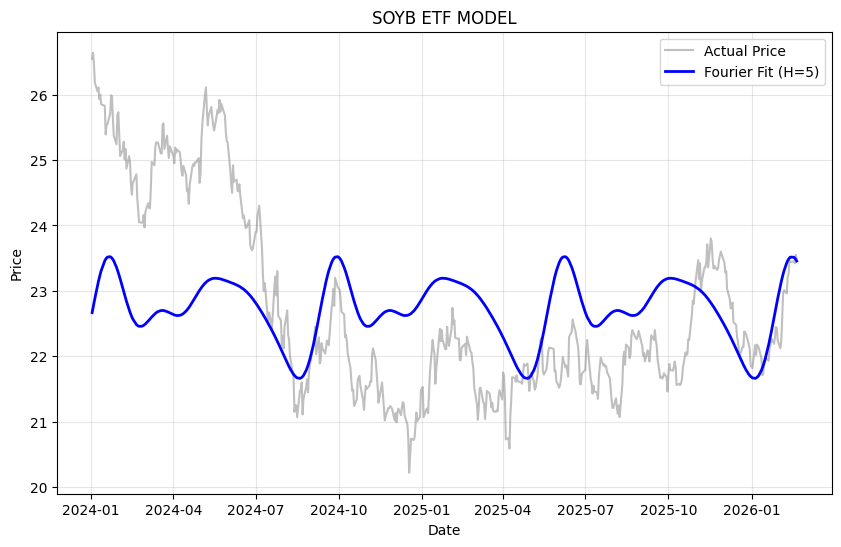

In [49]:
soyb_days, soyb_price, soyb_dates = csv_reader("data/soyb_etf.csv") 

# 2. FIT THE MODEL
# Crucial: Pass 'corn_days' (integers) to the math function, NOT dates
harmonics = 5
y_fit, coeffs = fit_fourier_series(soyb_days, soyb_price, harmonics, 252)

# 3. PLOT
plt.figure(figsize=(10, 6))

plt.plot(soyb_dates, soyb_price, label='Actual Price', color='gray', alpha=0.5)
plt.plot(soyb_dates, y_fit, label=f'Fourier Fit (H={harmonics})', color='blue', linewidth=2)

plt.title("SOYB ETF MODEL")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

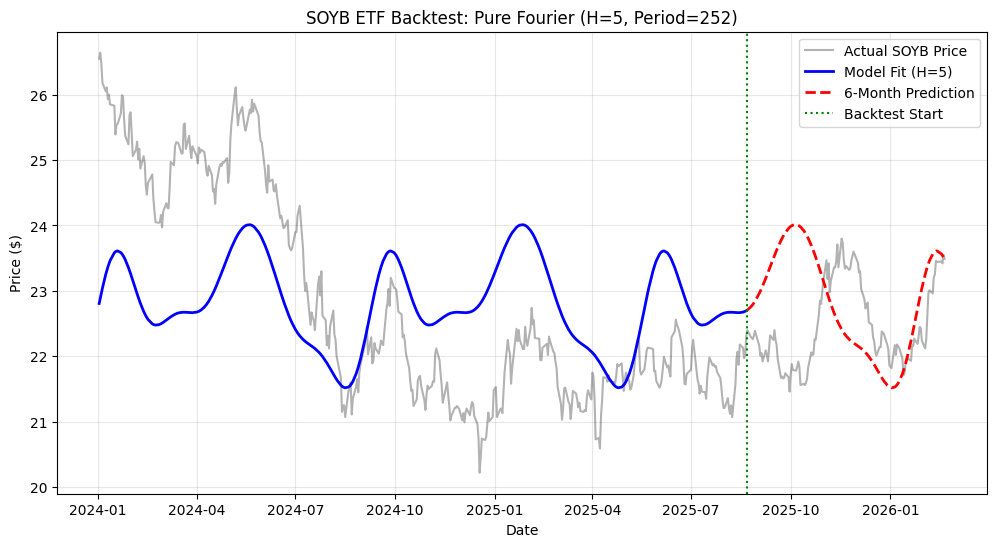

Mean Absolute Error (MAE) on 6-Month SOYB Prediction: $0.9418


In [50]:
# 1. Load Data
soyb_days, soyb_price, soyb_dates = csv_reader('data/soyb_etf.csv') 

# 2. Define Split (Last 6 months for prediction)
cutoff_date = soyb_dates[-1] - np.timedelta64(182, 'D')
cutoff = np.searchsorted(soyb_dates, cutoff_date)

x_train, y_train = soyb_days[:cutoff], soyb_price[:cutoff]
x_test, y_test = soyb_days[cutoff:], soyb_price[cutoff:]

# 3. Fit Model using your fit_fourier_series function
harmonics = 5  # H=5 is the sweet spot for commodity cycles
custom_period = 252  # Trading days in a year

# Get the fit and the coeffs from your function
y_fit_train, coeffs = fit_fourier_series(x_train, y_train, harmonics, period=custom_period)

# 4. Predict the Future
# Since your function returns a pre-multiplied y_fit, we manually 
# rebuild the A matrix for the FULL range to project those coeffs.
omega = 2 * np.pi / custom_period

A_full = [np.ones_like(soyb_days)]
for n in range(1, harmonics + 1):
    A_full.append(np.cos(n * omega * soyb_days))
    A_full.append(np.sin(n * omega * soyb_days))
A_full = np.vstack(A_full).T

# Apply the training coefficients to the full timeline
y_prediction = A_full @ coeffs

# 5. Plotting
plt.figure(figsize=(12, 6))

# Actual Data
plt.plot(soyb_dates, soyb_price, color='black', alpha=0.3, label='Actual SOYB Price')

# Blue Line: How the model fits the past
plt.plot(soyb_dates[:cutoff], y_prediction[:cutoff], color='blue', linewidth=2, label=f'Model Fit (H={harmonics})')

# Red Dashed Line: The "Unseen" 6-month prediction
plt.plot(soyb_dates[cutoff:], y_prediction[cutoff:], color='red', linestyle='--', linewidth=2, label='6-Month Prediction')

plt.axvline(x=soyb_dates[cutoff], color='green', linestyle=':', label='Backtest Start')

plt.title(f"SOYB ETF Backtest: Pure Fourier (H={harmonics}, Period={custom_period})")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 7. Accuracy Metrics
mae  = np.mean(np.abs(y_prediction[cutoff:] - y_test))
rmse = np.sqrt(np.mean((y_prediction[cutoff:] - y_test)**2))
mape = np.mean(np.abs((y_prediction[cutoff:] - y_test) / y_test)) * 100
ss_res = np.sum((y_test - y_prediction[cutoff:])**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - ss_res / ss_tot
print(f"SOYB ETF 6-Month Backtest | MAE: ${mae:.4f}  RMSE: ${rmse:.4f}  MAPE: {mape:.2f}%  R\u00b2: {r2:.4f}")


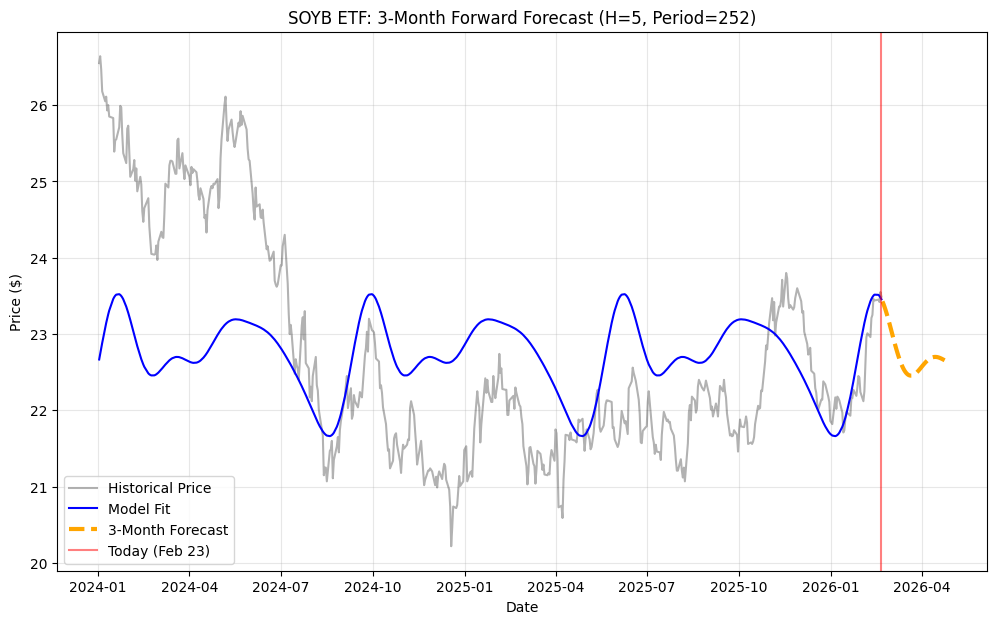

In [51]:
# 1. Load the full dataset
soyb_days, soyb_price, soyb_dates = csv_reader('data/soyb_etf.csv')

# 2. Fit the Model on EVERYTHING (H=5, Period=252)
harmonics = 5
custom_period = 252
y_fit_full, coeffs = fit_fourier_series(soyb_days, soyb_price, harmonics, period=custom_period)

# 3. Generate Future Days (Next 3 Months / ~63 Trading Days)
future_days_count = 63
last_day = soyb_days[-1]
future_days = np.arange(last_day + 1, last_day + future_days_count + 1)

# Generate Future Dates for the X-axis
last_date = soyb_dates[-1]
future_dates = np.array([last_date + np.timedelta64(i, 'D') for i in range(1, future_days_count + 1)])

# Combine all days for the final projection
all_days = np.concatenate([soyb_days, future_days])
all_dates = np.concatenate([soyb_dates, future_dates])

# 4. Apply Coefficients to the Future
omega = 2 * np.pi / custom_period
A_forecast = [np.ones_like(all_days)]
for n in range(1, harmonics + 1):
    A_forecast.append(np.cos(n * omega * all_days))
    A_forecast.append(np.sin(n * omega * all_days))
A_forecast = np.vstack(A_forecast).T

# Final Forecast Calculation
y_forecast = A_forecast @ coeffs

# 5. Plotting the Outlook
plt.figure(figsize=(12, 7))

# Actual Price History
plt.plot(soyb_dates, soyb_price, color='black', alpha=0.3, label='Historical Price')

# Model Fit on History
plt.plot(soyb_dates, y_forecast[:len(soyb_days)], color='blue', label='Model Fit')

# The 3-Month Projection
plt.plot(future_dates, y_forecast[len(soyb_days):], color='orange', linestyle='--', linewidth=3, label='3-Month Forecast')

# Today's Marker
plt.axvline(x=soyb_dates[-1], color='red', linestyle='-', alpha=0.5, label='Today (Feb 23)')

plt.title(f"SOYB ETF: 3-Month Forward Forecast (H={harmonics}, Period={custom_period})")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


--- 3-MONTH FORECAST TURNING POINTS ---
LOCAL MAXIMA (Exit/Caution Zone):
Date: 2026-04-15T00:00:00.000000000 | Price: $22.70

LOCAL MINIMA (Put Profit Targets):
Date: 2026-03-21T00:00:00.000000000 | Price: $22.46


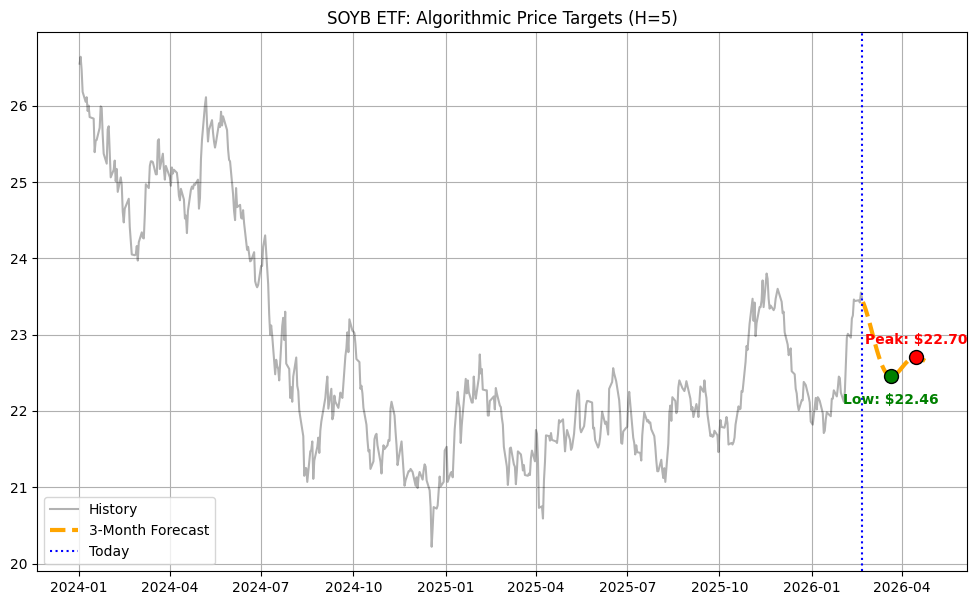

In [ ]:
# 1. RUN YOUR EXISTING FORECAST LOGIC
# (Ensure soyb_days, soyb_price, and y_forecast are already calculated)

# 2. ISOLATE THE 3-MONTH PREDICTION SEGMENT
# We only care about the turning points in the 'Future'
future_segment = y_forecast[len(soyb_days):]
future_dates_segment = future_dates

# 3. FIND LOCAL MINIMA & MAXIMA
# 'order=5' ensures we find significant swings rather than daily noise
max_idx = argrelextrema(future_segment, np.greater, order=5)[0]
min_idx = argrelextrema(future_segment, np.less, order=5)[0]

# 4. PRINT THE SIGNALS
print("\n--- 3-MONTH FORECAST TURNING POINTS ---")
print("LOCAL MAXIMA (Exit/Caution Zone):")
for i in max_idx:
    print(f"Date: {future_dates_segment[i].astype(str)} | Price: ${future_segment[i]:.2f}")

print("\nLOCAL MINIMA (Put Profit Targets):")
for i in min_idx:
    print(f"Date: {future_dates_segment[i].astype(str)} | Price: ${future_segment[i]:.2f}")

# 5. UPDATED PLOT WITH ANNOTATIONS
plt.figure(figsize=(12, 7))
plt.plot(soyb_dates, soyb_price, color='black', alpha=0.3, label='History')
plt.plot(future_dates, future_segment, color='orange', linestyle='--', linewidth=3, label='3-Month Forecast')

# Mark the Peaks (Red)
for i in max_idx:
    plt.scatter(future_dates_segment[i], future_segment[i], color='red', s=100, edgecolors='black', zorder=5)
    plt.annotate(f'Peak: ${future_segment[i]:.2f}', (future_dates_segment[i], future_segment[i]), 
                 xytext=(0,10), textcoords="offset points", ha='center', color='red', fontweight='bold')

# Mark the Lows (Green)
for i in min_idx:
    plt.scatter(future_dates_segment[i], future_segment[i], color='green', s=100, edgecolors='black', zorder=5)
    plt.annotate(f'Low: ${future_segment[i]:.2f}', (future_dates_segment[i], future_segment[i]), 
                 xytext=(0,-20), textcoords="offset points", ha='center', color='green', fontweight='bold')

plt.axvline(x=soyb_dates[-1], color='blue', linestyle=':', label='Today')
plt.title(f"SOYB ETF: Algorithmic Price Targets (H={harmonics})")
plt.legend()
plt.grid(True)
plt.show()